In [2]:
# ── CELDA 1: Configuración Telegram ──────────────────────────────────────
# Obtener en: https://my.telegram.org → API development tools
from dotenv import load_dotenv
load_dotenv()
import os

API_ID   = os.getenv("TELEGRAM_API_ID")
API_HASH = os.getenv("TELEGRAM_API_HASH")
CHANNEL  = 'Immortal_Chess_Network'

In [2]:
# ── CELDA 2: Scraper completo ─────────────────────────────────────────────
import re
import asyncio
import pandas as pd
import numpy as np
from telethon import TelegramClient
from telethon.tl.types import MessageMediaDocument, MessageMediaPhoto
from datetime import datetime

In [ ]:


# ── PATRONES DE EXTRACCIÓN ───────────────────────────────────────────────

# Dominios de cursos conocidos
COURSE_DOMAINS = {
    'chessable.com':    'chessable',
    'modernchess.com':  'modern_chess',
    'udemy.com':        'udemy',
    'chess.com':        'chess.com',
    'lichess.org':      'lichess',
    'chessmood.com':    'chessmood',
    'chessly.com':      'chessly',
    'youtube.com':      'youtube',
    'youtu.be':         'youtube',
}

# Extensiones de archivo relevantes
FILE_EXTENSIONS = {
    '.pgn':  'pgn',
    '.zip':  'zip',
    '.pdf':  'pdf',
    '.cbv':  'cbv',   # ChessBase
    '.cbz':  'cbz',
    '.epub': 'epub',
}

# Señales de nivel — mismas que el pipeline principal
BEGINNER_SIGNALS = [
    'beginner', 'basics', 'fundamental', 'starter', 'easy',
    'simple', 'dummies', '101', 'introduction', 'intro',
    'learn chess', 'first steps', 'new to chess', 'getting started',
    'kids', 'children', 'complete beginner', 'quick start',
]

INTERMEDIATE_SIGNALS = [
    'intermediate', 'club player', 'improving', '1200', '1400',
    '1500', '1600', 'practical', 'common mistakes',
]

ADVANCED_SIGNALS = [
    'advanced', 'master', 'grandmaster', 'gm ', 'im ', 'titled',
    'prophylaxis', 'deep', 'mastery', '2000', '2200', '2000+',
    'in-depth', 'complete repertoire', 'gm repertoire',
    'according to', 'professional',
]

# Tipos de curso
OPENING_KEYWORDS = [
    'sicilian', 'french', 'caro', 'ruy lopez', 'italian', 'london',
    'queens gambit', "queen's gambit", 'kings indian', "king's indian",
    'nimzo', 'grunfeld', 'grünfeld', 'pirc', 'dutch', 'english',
    'catalan', 'slav', 'benoni', 'budapest', 'alekhine', 'scandinavian',
    'opening', 'repertoire', 'defense', 'defence', 'gambit',
]

COURSE_TYPE_SIGNALS = {
    'opening':    OPENING_KEYWORDS,
    'endgame':    ['endgame', 'end game', 'rook ending', 'pawn ending', 'endings'],
    'tactics':    ['tactics', 'combinations', 'puzzles', 'calculation'],
    'middlegame': ['middlegame', 'middle game', 'strategy', 'positional'],
    'general':    ['complete chess', 'chess improvement', 'fundamentals'],
}

COLOR_SIGNALS = {
    'White': ['for white', 'with white', 'playing white', 'as white', '1.e4', '1.d4', '1.nf3', '1.c4'],
    'Black': ['for black', 'with black', 'playing black', 'as black', 'against 1.e4', 'against 1.d4'],
}


# ── FUNCIONES DE EXTRACCIÓN ───────────────────────────────────────────────

def extract_urls(text: str) -> list:
    return re.findall(r'https?://[^\s\)\]>\"\']+', text)

def extract_source(url: str) -> str:
    for domain, source in COURSE_DOMAINS.items():
        if domain in url:
            return source
    return 'telegram'

def infer_level(text: str) -> str:
    t = text.lower()
    
    # Buscar rating explícito tipo "1800-2200" o "for 1500+"
    rating_match = re.search(r'\b(\d{3,4})\s*[-+]?\s*(\d{3,4})?\b', text)
    if rating_match:
        rating = int(rating_match.group(1))
        if rating < 1200:   return 'beginner'
        if rating < 1800:   return 'intermediate'
        if rating >= 1800:  return 'advanced'

    down = sum(1 for s in BEGINNER_SIGNALS     if s in t)
    mid  = sum(1 for s in INTERMEDIATE_SIGNALS if s in t)
    up   = sum(1 for s in ADVANCED_SIGNALS     if s in t)

    if down >= 1 and up == 0:   return 'beginner'
    if up >= 2 and down == 0:   return 'advanced'
    if up >= 1 and mid >= 1:    return 'intermediate'
    if mid >= 1:                return 'intermediate'
    if up >= 1:                 return 'advanced'
    return 'intermediate'  # default conservador

def infer_course_type(text: str) -> str:
    t = text.lower()
    for ctype, signals in COURSE_TYPE_SIGNALS.items():
        if any(s in t for s in signals):
            return ctype
    return 'general'

def infer_color(text: str) -> str:
    t = text.lower()
    for color, signals in COLOR_SIGNALS.items():
        if any(s in t for s in signals):
            return color
    return 'Both'

def infer_file_format(filename: str) -> str:
    for ext, fmt in FILE_EXTENSIONS.items():
        if filename.lower().endswith(ext):
            return fmt
    return 'unknown'

def extract_title(text: str, url: str = '') -> str:
    """Extrae el mejor título disponible del mensaje."""
    # Limpiar URLs y caracteres especiales
    clean = re.sub(r'https?://\S+', '', text).strip()
    clean = re.sub(r'[#*_`]', '', clean)
    
    # Primera línea no vacía como título
    lines = [l.strip() for l in clean.split('\n') if l.strip()]
    if lines:
        return lines[0][:120]
    
    # Fallback: extraer slug de la URL
    if url:
        slug = url.rstrip('/').split('/')[-1]
        return re.sub(r'[-_]', ' ', slug).title()[:120]
    
    return 'Unknown'

def make_resource_id(source: str, title: str, msg_id: int) -> str:
    clean = re.sub(r'[^a-z0-9]', '_', title.lower())[:30]
    return f"tg_{source}__{clean}__{msg_id}"


# ── SCRAPER PRINCIPAL ─────────────────────────────────────────────────────

async def scrape_telegram_channel(
    api_id, api_hash, channel,
    limit: int = 5000,          # máx mensajes a leer
    min_date: str = '2022-01-01'
) -> pd.DataFrame:

    rows = []
    min_dt = datetime.strptime(min_date, '%Y-%m-%d')

    async with TelegramClient('chess_session', api_id, api_hash) as client:
        print(f"✅ Conectado a Telegram")
        
        entity = await client.get_entity(channel)
        print(f"✅ Canal: {entity.title if hasattr(entity, 'title') else channel}")

        msg_count = 0
        resource_count = 0

        async for message in client.iter_messages(entity, limit=limit):
            msg_count += 1

            # Filtro de fecha
            if message.date.replace(tzinfo=None) < min_dt:
                continue

            text = message.text or ''
            if not text and not message.media:
                continue

            # ── CASO 1: Mensaje con URL de curso ─────────────────────────
            urls = extract_urls(text)
            for url in urls:
                source = extract_source(url)
                if source == 'telegram':
                    continue  # ignorar links no reconocidos

                title      = extract_title(text, url)
                level      = infer_level(text)
                ctype      = infer_course_type(text)
                color      = infer_color(text)

                row = {
                    'resource_id':   make_resource_id(source, title, message.id),
                    'source':        source,
                    'title':         title,
                    'url':           url,
                    'resource_type': 'course',
                    'format':        'video' if source == 'youtube' else 'interactive',
                    'course_type':   ctype,
                    'openings':      '',
                    'color':         color,
                    'author':        '',
                    'author_title':  '',
                    'level_min':     np.nan,
                    'level_max':     np.nan,
                    'level_tier':    level,
                    'level_tier_original': level,
                    'level_tier_new':      level,
                    'level_tier_source':   'telegram_inferred',
                    'duration_min':  np.nan,
                    'price_eur':     np.nan,
                    'is_free':       0,
                    'has_video':     1 if source == 'youtube' else 0,
                    'has_pgn':       0,
                    'has_exercises': 0,
                    'has_spaced_rep':0,
                    'rating_score':  np.nan,
                    'n_reviews':     np.nan,
                    'views_yt':      np.nan,
                    'pub_date':      message.date.strftime('%Y-%m-%d'),
                    'description':   text[:300],
                    'tags':          np.nan,
                    'score_up':      sum(1 for s in ADVANCED_SIGNALS     if s in text.lower()),
                    'score_down':    sum(1 for s in BEGINNER_SIGNALS     if s in text.lower()),
                    'score_anchor':  sum(1 for s in INTERMEDIATE_SIGNALS if s in text.lower()),
                }
                rows.append(row)
                resource_count += 1

            # ── CASO 2: Archivo adjunto (PGN, ZIP, PDF) ──────────────────
            if message.media and isinstance(message.media, MessageMediaDocument):
                doc = message.media.document
                filename = ''
                for attr in doc.attributes:
                    if hasattr(attr, 'file_name'):
                        filename = attr.file_name
                        break

                if not filename:
                    continue

                fmt = infer_file_format(filename)
                if fmt == 'unknown':
                    continue

                title = extract_title(
                    text if text else filename.replace('_', ' ').replace('-', ' '),
                    ''
                )
                level = infer_level(f"{title} {text}")
                ctype = infer_course_type(f"{title} {text}")
                color = infer_color(f"{title} {text}")

                row = {
                    'resource_id':   make_resource_id('tg_file', filename, message.id),
                    'source':        'telegram_file',
                    'title':         title,
                    'url':           f'telegram://msg/{message.id}',
                    'resource_type': 'book' if fmt == 'pdf' else 'course',
                    'format':        fmt,
                    'course_type':   ctype,
                    'openings':      '',
                    'color':         color,
                    'author':        '',
                    'author_title':  '',
                    'level_min':     np.nan,
                    'level_max':     np.nan,
                    'level_tier':    level,
                    'level_tier_original': level,
                    'level_tier_new':      level,
                    'level_tier_source':   'telegram_filename',
                    'duration_min':  np.nan,
                    'price_eur':     np.nan,
                    'is_free':       1,    # compartido en el canal = accesible
                    'has_video':     0,
                    'has_pgn':       1 if fmt == 'pgn' else 0,
                    'has_exercises': 0,
                    'has_spaced_rep':0,
                    'rating_score':  np.nan,
                    'n_reviews':     np.nan,
                    'views_yt':      np.nan,
                    'pub_date':      message.date.strftime('%Y-%m-%d'),
                    'description':   text[:300] if text else filename,
                    'tags':          np.nan,
                    'score_up':      sum(1 for s in ADVANCED_SIGNALS     if s in f"{title} {text}".lower()),
                    'score_down':    sum(1 for s in BEGINNER_SIGNALS     if s in f"{title} {text}".lower()),
                    'score_anchor':  sum(1 for s in INTERMEDIATE_SIGNALS if s in f"{title} {text}".lower()),
                }
                rows.append(row)
                resource_count += 1

            if msg_count % 500 == 0:
                print(f"  ... {msg_count} mensajes procesados, {resource_count} recursos encontrados")

    df = pd.DataFrame(rows).drop_duplicates('resource_id')
    return df


# ── EJECUTAR Y REPORTAR ───────────────────────────────────────────────────

async def run():
    df_tg = await scrape_telegram_channel(
        api_id   = API_ID,
        api_hash = API_HASH,
        channel  = CHANNEL,
        limit    = 5000,
        min_date = '2022-01-01',
    )

    if df_tg.empty:
        print("⚠️  Sin resultados")
        return

    # Reporte
    print(f"\n{'='*50}")
    print(f"RESULTADOS TELEGRAM")
    print(f"{'='*50}")
    print(f"Total recursos extraídos: {len(df_tg)}")
    print(f"\n── Por nivel ──")
    print(df_tg['level_tier'].value_counts().to_string())
    print(f"\n── Por fuente ──")
    print(df_tg['source'].value_counts().to_string())
    print(f"\n── Por tipo de curso ──")
    print(df_tg['course_type'].value_counts().to_string())
    print(f"\n── Por formato de archivo ──")
    print(df_tg['format'].value_counts().to_string())

    # Muestra de beginner encontrados
    beg = df_tg[df_tg['level_tier'] == 'beginner']
    print(f"\n── Beginner encontrados: {len(beg)} ──")
    if len(beg):
        print(beg[['title', 'source', 'course_type', 'format']].head(10).to_string(index=False))

    # Guardar
    df_tg.to_csv('src_telegram.csv', index=False)
    print(f"\n✅ src_telegram.csv guardado")

    # Merge con dataset base
    df_base = pd.read_csv(r'C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\chess_resources_3tier.csv')
    df_new  = df_tg[~df_tg['resource_id'].isin(df_base['resource_id'])]
    df_combined = pd.concat([df_base, df_new], ignore_index=True)
    df_combined.to_csv('chess_resources_final.csv', index=False)

    order = ['beginner', 'intermediate', 'advanced']
    dist  = df_combined['level_tier'].value_counts().reindex(order)
    dist_pct = df_combined['level_tier'].value_counts(normalize=True).reindex(order) * 100
    print(f"\n── Distribución final combinada ──")
    for tier in order:
        print(f"  {tier:<15} {dist[tier]:>6}  {dist_pct[tier]:>5.1f}%")
    print(f"  {'TOTAL':<15} {dist.sum():>6}")
    print(f"\n✅ chess_resources_final.csv guardado")

    return df_combined

df_combined = await run()

✅ Conectado a Telegram
✅ Canal: IMC – Immortal Chess Network
  ... 500 mensajes procesados, 61 recursos encontrados
  ... 1000 mensajes procesados, 98 recursos encontrados
  ... 1500 mensajes procesados, 161 recursos encontrados
  ... 2000 mensajes procesados, 243 recursos encontrados
  ... 2500 mensajes procesados, 313 recursos encontrados
  ... 3000 mensajes procesados, 356 recursos encontrados
  ... 3500 mensajes procesados, 408 recursos encontrados
  ... 4000 mensajes procesados, 483 recursos encontrados
  ... 4500 mensajes procesados, 513 recursos encontrados

RESULTADOS TELEGRAM
Total recursos extraídos: 542

── Por nivel ──
level_tier
intermediate    312
beginner        127
advanced        103

── Por fuente ──
source
telegram_file    245
chessable        146
chess.com        132
youtube           10
chessmood          6
lichess            3

── Por tipo de curso ──
course_type
opening       318
general       184
endgame        20
tactics        11
middlegame      9

── Por form

In [ ]:
# ── CELDA 2: Scraper completo ─────────────────────────────────────────────
import re
import asyncio
import pandas as pd
import numpy as np
from telethon import TelegramClient
from telethon.tl.types import MessageMediaDocument, MessageMediaPhoto
from datetime import datetime

# ── PATRONES DE EXTRACCIÓN ───────────────────────────────────────────────

# Dominios de cursos conocidos
COURSE_DOMAINS = {
    'chessable.com':    'chessable',
    'modernchess.com':  'modern_chess',
    'udemy.com':        'udemy',
    'chess.com':        'chess.com',
    'lichess.org':      'lichess',
    'chessmood.com':    'chessmood',
    'chessly.com':      'chessly',
    'youtube.com':      'youtube',
    'youtu.be':         'youtube',
}

# Extensiones de archivo relevantes
FILE_EXTENSIONS = {
    '.pgn':  'pgn',
    '.zip':  'zip',
    '.pdf':  'pdf',
    '.cbv':  'cbv',   # ChessBase
    '.cbz':  'cbz',
    '.epub': 'epub',
}

# Señales de nivel — mismas que el pipeline principal
BEGINNER_SIGNALS = [
    'beginner', 'basics', 'fundamental', 'starter', 'easy',
    'simple', 'dummies', '101', 'introduction', 'intro',
    'learn chess', 'first steps', 'new to chess', 'getting started',
    'kids', 'children', 'complete beginner', 'quick start',
]

INTERMEDIATE_SIGNALS = [
    'intermediate', 'club player', 'improving', '1200', '1400',
    '1500', '1600', 'practical', 'common mistakes',
]

ADVANCED_SIGNALS = [
    'advanced', 'master', 'grandmaster', 'gm ', 'im ', 'titled',
    'prophylaxis', 'deep', 'mastery', '2000', '2200', '2000+',
    'in-depth', 'complete repertoire', 'gm repertoire',
    'according to', 'professional',
]

# Tipos de curso
OPENING_KEYWORDS = [
    'sicilian', 'french', 'caro', 'ruy lopez', 'italian', 'london',
    'queens gambit', "queen's gambit", 'kings indian', "king's indian",
    'nimzo', 'grunfeld', 'grünfeld', 'pirc', 'dutch', 'english',
    'catalan', 'slav', 'benoni', 'budapest', 'alekhine', 'scandinavian',
    'opening', 'repertoire', 'defense', 'defence', 'gambit',
]

COURSE_TYPE_SIGNALS = {
    'opening':    OPENING_KEYWORDS,
    'endgame':    ['endgame', 'end game', 'rook ending', 'pawn ending', 'endings'],
    'tactics':    ['tactics', 'combinations', 'puzzles', 'calculation'],
    'middlegame': ['middlegame', 'middle game', 'strategy', 'positional'],
    'general':    ['complete chess', 'chess improvement', 'fundamentals'],
}

COLOR_SIGNALS = {
    'White': ['for white', 'with white', 'playing white', 'as white', '1.e4', '1.d4', '1.nf3', '1.c4'],
    'Black': ['for black', 'with black', 'playing black', 'as black', 'against 1.e4', 'against 1.d4'],
}


# ── FUNCIONES DE EXTRACCIÓN ───────────────────────────────────────────────

def extract_urls(text: str) -> list:
    return re.findall(r'https?://[^\s\)\]>\"\']+', text)

def extract_source(url: str) -> str:
    for domain, source in COURSE_DOMAINS.items():
        if domain in url:
            return source
    return 'telegram'

def infer_level(text: str) -> str:
    t = text.lower()
    
    # Buscar rating explícito tipo "1800-2200" o "for 1500+"
    rating_match = re.search(r'\b(\d{3,4})\s*[-+]?\s*(\d{3,4})?\b', text)
    if rating_match:
        rating = int(rating_match.group(1))
        if rating < 1200:   return 'beginner'
        if rating < 1800:   return 'intermediate'
        if rating >= 1800:  return 'advanced'

    down = sum(1 for s in BEGINNER_SIGNALS     if s in t)
    mid  = sum(1 for s in INTERMEDIATE_SIGNALS if s in t)
    up   = sum(1 for s in ADVANCED_SIGNALS     if s in t)

    if down >= 1 and up == 0:   return 'beginner'
    if up >= 2 and down == 0:   return 'advanced'
    if up >= 1 and mid >= 1:    return 'intermediate'
    if mid >= 1:                return 'intermediate'
    if up >= 1:                 return 'advanced'
    return 'intermediate'  # default conservador

def infer_course_type(text: str) -> str:
    t = text.lower()
    for ctype, signals in COURSE_TYPE_SIGNALS.items():
        if any(s in t for s in signals):
            return ctype
    return 'general'

def infer_color(text: str) -> str:
    t = text.lower()
    for color, signals in COLOR_SIGNALS.items():
        if any(s in t for s in signals):
            return color
    return 'Both'

def infer_file_format(filename: str) -> str:
    for ext, fmt in FILE_EXTENSIONS.items():
        if filename.lower().endswith(ext):
            return fmt
    return 'unknown'

def extract_title(text: str, url: str = '') -> str:
    """Extrae el mejor título disponible del mensaje."""
    # Limpiar URLs y caracteres especiales
    clean = re.sub(r'https?://\S+', '', text).strip()
    clean = re.sub(r'[#*_`]', '', clean)
    
    # Primera línea no vacía como título
    lines = [l.strip() for l in clean.split('\n') if l.strip()]
    if lines:
        return lines[0][:120]
    
    # Fallback: extraer slug de la URL
    if url:
        slug = url.rstrip('/').split('/')[-1]
        return re.sub(r'[-_]', ' ', slug).title()[:120]
    
    return 'Unknown'

def make_resource_id(source: str, title: str, msg_id: int) -> str:
    clean = re.sub(r'[^a-z0-9]', '_', title.lower())[:30]
    return f"tg_{source}__{clean}__{msg_id}"


# ── SCRAPER PRINCIPAL ─────────────────────────────────────────────────────

async def scrape_telegram_channel(
    api_id, api_hash, channel,
    limit: int = 5000,          # máx mensajes a leer
    min_date: str = '2022-01-01'
) -> pd.DataFrame:

    rows = []
    min_dt = datetime.strptime(min_date, '%Y-%m-%d')

    async with TelegramClient('chess_session', api_id, api_hash) as client:
        print(f"✅ Conectado a Telegram")
        
        entity = await client.get_entity(channel)
        print(f"✅ Canal: {entity.title if hasattr(entity, 'title') else channel}")

        msg_count = 0
        resource_count = 0

        async for message in client.iter_messages(entity, limit=limit):
            msg_count += 1

            # Filtro de fecha
            if message.date.replace(tzinfo=None) < min_dt:
                continue

            text = message.text or ''
            if not text and not message.media:
                continue

            # ── CASO 1: Mensaje con URL de curso ─────────────────────────
            urls = extract_urls(text)
            for url in urls:
                source = extract_source(url)
                if source == 'telegram':
                    continue  # ignorar links no reconocidos

                title      = extract_title(text, url)
                level      = infer_level(text)
                ctype      = infer_course_type(text)
                color      = infer_color(text)

                row = {
                    'resource_id':   make_resource_id(source, title, message.id),
                    'source':        source,
                    'title':         title,
                    'url':           url,
                    'resource_type': 'course',
                    'format':        'video' if source == 'youtube' else 'interactive',
                    'course_type':   ctype,
                    'openings':      '',
                    'color':         color,
                    'author':        '',
                    'author_title':  '',
                    'level_min':     np.nan,
                    'level_max':     np.nan,
                    'level_tier':    level,
                    'level_tier_original': level,
                    'level_tier_new':      level,
                    'level_tier_source':   'telegram_inferred',
                    'duration_min':  np.nan,
                    'price_eur':     np.nan,
                    'is_free':       0,
                    'has_video':     1 if source == 'youtube' else 0,
                    'has_pgn':       0,
                    'has_exercises': 0,
                    'has_spaced_rep':0,
                    'rating_score':  np.nan,
                    'n_reviews':     np.nan,
                    'views_yt':      np.nan,
                    'pub_date':      message.date.strftime('%Y-%m-%d'),
                    'description':   text[:300],
                    'tags':          np.nan,
                    'score_up':      sum(1 for s in ADVANCED_SIGNALS     if s in text.lower()),
                    'score_down':    sum(1 for s in BEGINNER_SIGNALS     if s in text.lower()),
                    'score_anchor':  sum(1 for s in INTERMEDIATE_SIGNALS if s in text.lower()),
                }
                rows.append(row)
                resource_count += 1

            # ── CASO 2: Archivo adjunto (PGN, ZIP, PDF) ──────────────────
            if message.media and isinstance(message.media, MessageMediaDocument):
                doc = message.media.document
                filename = ''
                for attr in doc.attributes:
                    if hasattr(attr, 'file_name'):
                        filename = attr.file_name
                        break

                if not filename:
                    continue

                fmt = infer_file_format(filename)
                if fmt == 'unknown':
                    continue

                title = extract_title(
                    text if text else filename.replace('_', ' ').replace('-', ' '),
                    ''
                )
                level = infer_level(f"{title} {text}")
                ctype = infer_course_type(f"{title} {text}")
                color = infer_color(f"{title} {text}")

                row = {
                    'resource_id':   make_resource_id('tg_file', filename, message.id),
                    'source':        'telegram_file',
                    'title':         title,
                    'url':           f'telegram://msg/{message.id}',
                    'resource_type': 'book' if fmt == 'pdf' else 'course',
                    'format':        fmt,
                    'course_type':   ctype,
                    'openings':      '',
                    'color':         color,
                    'author':        '',
                    'author_title':  '',
                    'level_min':     np.nan,
                    'level_max':     np.nan,
                    'level_tier':    level,
                    'level_tier_original': level,
                    'level_tier_new':      level,
                    'level_tier_source':   'telegram_filename',
                    'duration_min':  np.nan,
                    'price_eur':     np.nan,
                    'is_free':       1,    # compartido en el canal = accesible
                    'has_video':     0,
                    'has_pgn':       1 if fmt == 'pgn' else 0,
                    'has_exercises': 0,
                    'has_spaced_rep':0,
                    'rating_score':  np.nan,
                    'n_reviews':     np.nan,
                    'views_yt':      np.nan,
                    'pub_date':      message.date.strftime('%Y-%m-%d'),
                    'description':   text[:300] if text else filename,
                    'tags':          np.nan,
                    'score_up':      sum(1 for s in ADVANCED_SIGNALS     if s in f"{title} {text}".lower()),
                    'score_down':    sum(1 for s in BEGINNER_SIGNALS     if s in f"{title} {text}".lower()),
                    'score_anchor':  sum(1 for s in INTERMEDIATE_SIGNALS if s in f"{title} {text}".lower()),
                }
                rows.append(row)
                resource_count += 1

            if msg_count % 500 == 0:
                print(f"  ... {msg_count} mensajes procesados, {resource_count} recursos encontrados")

    df = pd.DataFrame(rows).drop_duplicates('resource_id')
    return df


# ── EJECUTAR Y REPORTAR ───────────────────────────────────────────────────

async def run():
    df_tg = await scrape_telegram_channel(
        api_id   = API_ID,
        api_hash = API_HASH,
        channel  = CHANNEL,
        limit    = 5000,
        min_date = '2022-01-01',
    )

    if df_tg.empty:
        print("⚠️  Sin resultados")
        return

    # Reporte
    print(f"\n{'='*50}")
    print(f"RESULTADOS TELEGRAM")
    print(f"{'='*50}")
    print(f"Total recursos extraídos: {len(df_tg)}")
    print(f"\n── Por nivel ──")
    print(df_tg['level_tier'].value_counts().to_string())
    print(f"\n── Por fuente ──")
    print(df_tg['source'].value_counts().to_string())
    print(f"\n── Por tipo de curso ──")
    print(df_tg['course_type'].value_counts().to_string())
    print(f"\n── Por formato de archivo ──")
    print(df_tg['format'].value_counts().to_string())

    # Muestra de beginner encontrados
    beg = df_tg[df_tg['level_tier'] == 'beginner']
    print(f"\n── Beginner encontrados: {len(beg)} ──")
    if len(beg):
        print(beg[['title', 'source', 'course_type', 'format']].head(10).to_string(index=False))

    # Guardar
    df_tg.to_csv('src_telegram.csv', index=False)
    print(f"\n✅ src_telegram.csv guardado")

    # Merge con dataset base
    df_base = pd.read_csv(r'C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\chess_resources_3tier.csv')
    df_new  = df_tg[~df_tg['resource_id'].isin(df_base['resource_id'])]
    df_combined = pd.concat([df_base, df_new], ignore_index=True)
    df_combined.to_csv('chess_resources_final.csv', index=False)

    order = ['beginner', 'intermediate', 'advanced']
    dist  = df_combined['level_tier'].value_counts().reindex(order)
    dist_pct = df_combined['level_tier'].value_counts(normalize=True).reindex(order) * 100
    print(f"\n── Distribución final combinada ──")
    for tier in order:
        print(f"  {tier:<15} {dist[tier]:>6}  {dist_pct[tier]:>5.1f}%")
    print(f"  {'TOTAL':<15} {dist.sum():>6}")
    print(f"\n✅ chess_resources_final.csv guardado")

    return df_combined

df_combined = await run()

✅ Conectado a Telegram
✅ Canal: IMC – Immortal Chess Network
  ... 500 mensajes procesados, 58 recursos encontrados
  ... 1000 mensajes procesados, 98 recursos encontrados
  ... 1500 mensajes procesados, 161 recursos encontrados
  ... 2000 mensajes procesados, 243 recursos encontrados
  ... 2500 mensajes procesados, 313 recursos encontrados
  ... 3000 mensajes procesados, 356 recursos encontrados
  ... 4000 mensajes procesados, 483 recursos encontrados
  ... 4500 mensajes procesados, 513 recursos encontrados
  ... 5000 mensajes procesados, 549 recursos encontrados

RESULTADOS TELEGRAM
Total recursos extraídos: 542

── Por nivel ──
level_tier
intermediate    312
beginner        127
advanced        103

── Por fuente ──
source
telegram_file    245
chessable        146
chess.com        132
youtube           10
chessmood          6
lichess            3

── Por tipo de curso ──
course_type
opening       318
general       184
endgame        20
tactics        11
middlegame      9

── Por form

In [ ]:
# ── CELDA ÚNICA: Localizar archivos y unificar rutas ─────────────────────
import os
import glob

PROJECT_DIR = r'C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML'

print(f"Directorio del proyecto: {PROJECT_DIR}\n")
print("── CSVs encontrados ──")
for f in glob.glob(os.path.join(PROJECT_DIR, '**', '*.csv'), recursive=True):
    size = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<45} {size:>8.1f} KB  →  {f}")

print(f"\n── Directorio de trabajo actual ──")
print(f"  {os.getcwd()}")

Directorio del proyecto: C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML

── CSVs encontrados ──
  beginner_resources.csv                            42.9 KB  →  C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\beginner_resources.csv
  chess_resources_3tier.csv                        603.2 KB  →  C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\chess_resources_3tier.csv
  chess_resources_final.csv                        631.9 KB  →  C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\chess_resources_final.csv
  chess_resources_master.csv                       514.9 KB  →  C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\chess_resources_master.csv
  chess_resources_rebalanced.csv                   546.2 KB  →  C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\chess_resources_rebalanced.csv
  chess_resources_v2.csv                           562.0 KB  →  C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\chess_r

In [ ]:
import glob
import os

# Buscar src_telegram.csv en todo el disco
print("Buscando src_telegram.csv...\n")
for drive in ['C:\\Users\\Eneko\\Desktop', 'C:\\Users\\Eneko\\Documents', 'C:\\Users\\Eneko']:
    results = glob.glob(os.path.join(drive, '**', 'src_telegram.csv'), recursive=True)
    for r in results:
        size = os.path.getsize(r) / 1024
        print(f"✅ Encontrado: {r}  ({size:.1f} KB)")

# También revisar directorio actual y sus padres
for path in [os.getcwd(), os.path.dirname(os.getcwd())]:
    candidate = os.path.join(path, 'src_telegram.csv')
    if os.path.exists(candidate):
        print(f"✅ En cwd: {candidate}")

Buscando src_telegram.csv...

✅ Encontrado: C:\Users\Eneko\AppData\Local\Programs\Microsoft VS Code\src_telegram.csv  (186.0 KB)


In [ ]:
import shutil
import os

src  = r'C:\Users\Eneko\AppData\Local\Programs\Microsoft VS Code\src_telegram.csv'
dst  = r'C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src_telegram.csv'

shutil.copy2(src, dst)
print(f"✅ Copiado a: {dst}")
print(f"   Tamaño: {os.path.getsize(dst)/1024:.1f} KB")

✅ Copiado a: C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src_telegram.csv
   Tamaño: 186.0 KB


In [ ]:
import pandas as pd
import numpy as np
import re
import os

PROJECT_DIR = r'C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML'

# ── CARGAR src_telegram.csv ───────────────────────────────────────────────
path_tg = os.path.join(PROJECT_DIR, 'src_telegram.csv')

if not os.path.exists(path_tg):
    print(f"⚠️  No existe src_telegram.csv en {PROJECT_DIR}")
    print("   Debes ejecutar primero el scraper de Telegram")
else:
    df_tg = pd.read_csv(path_tg)
    print(f"✅ src_telegram.csv cargado: {len(df_tg)} filas")

    # ── FILTRO 1: Títulos que son ruido ──────────────────────────────────
    NOISE_PATTERNS = [
        r'^(request|anybody|anyone|does anyone|can someone|please|pls|plz)',
        r'(has pgn|send pgn|pgn please|pgn\?|share pgn)',
        r'^(pgn|pdf|zip|video|link)\s',
        r'^(thanks|thank you|thx|ty\b)',
        r'^(hi|hello|hey|good morning)',
        r'^(re:|fwd:|forwarded)',
        r'^\d{4,}$',
        r'^.{1,8}$',
    ]

    def is_noise(title):
        if not isinstance(title, str): return True
        t = title.lower().strip()
        return any(re.search(p, t, re.IGNORECASE) for p in NOISE_PATTERNS)

    mask_noise = df_tg['title'].apply(is_noise)
    df_clean = df_tg[~mask_noise].copy()
    print(f"  Ruido eliminado:       {mask_noise.sum()}")

    # ── FILTRO 2: URLs inválidas ──────────────────────────────────────────
    def is_valid_url(url):
        if not isinstance(url, str): return False
        return url.startswith('telegram://') or bool(re.match(r'https?://', url))

    mask_url = ~df_clean['url'].apply(is_valid_url)
    df_clean = df_clean[~mask_url].copy()
    print(f"  URLs inválidas:        {mask_url.sum()}")

    # ── FILTRO 3: Deduplicación ───────────────────────────────────────────
    def normalize(t):
        if not isinstance(t, str): return ''
        return re.sub(r'\s+', ' ', re.sub(r'[^a-z0-9\s]', '', t.lower().strip()))

    df_clean['_norm'] = df_clean['title'].apply(normalize)
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates('_norm').drop(columns=['_norm'])
    print(f"  Duplicados eliminados: {before - len(df_clean)}")

    # ── FILTRO 4: Limpiar títulos ─────────────────────────────────────────
    def clean_title(t):
        if not isinstance(t, str): return t
        t = re.sub(r'\.(pdf|pgn|zip|cbv|epub|cbz)$', '', t, flags=re.IGNORECASE)
        t = re.sub(r'^[\U00010000-\U0010ffff\u2600-\u26FF\u2700-\u27BF\s]+', '', t)
        return re.sub(r'\s+', ' ', t).strip()

    df_clean['title'] = df_clean['title'].apply(clean_title)

    # ── FILTRO 5: Reclasificar beginner sin señal real ────────────────────
    df_clean['score_down'] = pd.to_numeric(df_clean['score_down'], errors='coerce').fillna(0)
    df_clean['score_up']   = pd.to_numeric(df_clean['score_up'],   errors='coerce').fillna(0)

    mask_false_beg = (df_clean['level_tier'] == 'beginner') & (df_clean['score_down'] == 0)
    print(f"  Beginner sin señal real (→ intermediate): {mask_false_beg.sum()}")
    df_clean.loc[mask_false_beg, 'level_tier'] = 'intermediate'

    # ── GUARDAR ───────────────────────────────────────────────────────────
    path_clean = os.path.join(PROJECT_DIR, 'src_telegram_clean.csv')
    df_clean.to_csv(path_clean, index=False)
    print(f"\n✅ Guardado: {path_clean}")

    # ── REPORTE ───────────────────────────────────────────────────────────
    order = ['beginner', 'intermediate', 'advanced']
    dist  = df_clean['level_tier'].value_counts().reindex(order)
    print(f"\n── Distribución Telegram limpio ──")
    for tier in order:
        print(f"  {tier:<15} {dist[tier]:>5}")

    print(f"\n── Muestra beginner válidos ──")
    beg = df_clean[df_clean['level_tier'] == 'beginner']
    print(f"  Total: {len(beg)}")
    print(beg[['title', 'source', 'course_type', 'format', 'score_down']]
          .head(20).to_string(index=False))

    # ── MERGE CON BASE ────────────────────────────────────────────────────
    path_base  = os.path.join(PROJECT_DIR, 'chess_resources_3tier.csv')
    path_final = os.path.join(PROJECT_DIR, 'chess_resources_final.csv')

    df_base = pd.read_csv(path_base)

    for col in df_base.columns:
        if col not in df_clean.columns:
            df_clean[col] = np.nan

    df_new   = df_clean[~df_clean['resource_id'].isin(df_base['resource_id'])]
    df_final = pd.concat([df_base, df_new[df_base.columns]], ignore_index=True)

    targets  = {'beginner': 20, 'intermediate': 50, 'advanced': 30}
    dist_f   = df_final['level_tier'].value_counts().reindex(order)
    dist_pct = df_final['level_tier'].value_counts(normalize=True).reindex(order) * 100

    print(f"\n{'='*62}")
    print(f"DATASET FINAL COMBINADO")
    print(f"{'='*62}")
    print(f"{'Nivel':<15} {'N':>6} {'%':>7}  {'Obj':>5}  Estado")
    print(f"{'-'*62}")
    for tier in order:
        n, pct, tgt = dist_f[tier], dist_pct[tier], targets[tier]
        st = "✅" if pct >= tgt else "⚠️  BAJO"
        print(f"{tier:<15} {n:>6} {pct:>6.1f}%  {tgt:>4}%  {st}")
    print(f"{'-'*62}")
    print(f"{'TOTAL':<15} {dist_f.sum():>6}")
    print(f"Nuevos de Telegram:  {len(df_new)}")

    df_final.to_csv(path_final, index=False)
    print(f"\n✅ {path_final}")

✅ src_telegram.csv cargado: 542 filas
  Ruido eliminado:       219
  URLs inválidas:        0
  Duplicados eliminados: 26
  Beginner sin señal real (→ intermediate): 27

✅ Guardado: C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\src_telegram_clean.csv

── Distribución Telegram limpio ──
  beginner            7
  intermediate      201
  advanced           89

── Muestra beginner válidos ──
  Total: 7
                                                        title        source course_type format  score_down
       Luther Thomas Chess Coaching for Kids: The U10 Project telegram_file     general    pdf           1
                          CHESS COACHING FOR KIDS U10 PROJECT telegram_file     general    pdf           1
   1001 Chess Endgame Exercises for Beginners Thomas Willemze telegram_file     endgame    pdf           1
1001 Chess Endgame Exercises for Beginners IM Thomas Willemze telegram_file     endgame    pgn           1
                 AlanB Moves Ahead 2 Calculation

In [3]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML\chess_resources_final.csv')

# ¿De dónde vienen los 99 beginner actuales?
print("── Fuentes de beginner actuales ──")
beg = df[df['level_tier'] == 'beginner']
print(beg['source'].value_counts().to_string())

print("\n── Tipos de curso en beginner ──")
print(beg['course_type'].value_counts().to_string())

print("\n── Formatos en beginner ──")
print(beg['format'].value_counts().to_string())

── Fuentes de beginner actuales ──
source
modern_chess     41
chessable        26
youtube          19
telegram_file     7
manual            6

── Tipos de curso en beginner ──
course_type
opening       73
general       15
tactics        6
endgame        4
middlegame     1

── Formatos en beginner ──
format
video          51
interactive    37
text            4
pgn             4
pdf             3


In [4]:
import pandas as pd
import numpy as np
import os

PROJECT_DIR = r'C:\Users\Eneko\Desktop\Ejercicios Data\Proyectos\Proyecto ML'
df = pd.read_csv(os.path.join(PROJECT_DIR, 'chess_resources_final.csv'))

# ── Ajustar objetivos realistas basados en el catálogo real ──────────────
REALISTIC_TARGETS = {
    'beginner':     10,   # ~130 recursos — lo que el mercado ofrece
    'intermediate': 55,   # ~715 recursos — núcleo del catálogo
    'advanced':     35,   # ~455 recursos — bien representado
}

order    = ['beginner', 'intermediate', 'advanced']
dist     = df['level_tier'].value_counts().reindex(order)
dist_pct = df['level_tier'].value_counts(normalize=True).reindex(order) * 100

print("=" * 62)
print("DISTRIBUCIÓN FINAL ACEPTADA — chess_resources_final.csv")
print("=" * 62)
print(f"{'Nivel':<15} {'N':>6} {'%':>7}  {'Obj realista':>13}  Estado")
print("-" * 62)
for tier in order:
    n, pct, tgt = dist[tier], dist_pct[tier], REALISTIC_TARGETS[tier]
    st = "✅" if pct >= tgt else "⚠️  BAJO"
    print(f"{tier:<15} {n:>6} {pct:>6.1f}%  {tgt:>12}%  {st}")
print("-" * 62)
print(f"{'TOTAL':<15} {dist.sum():>6}")

DISTRIBUCIÓN FINAL ACEPTADA — chess_resources_final.csv
Nivel                N       %   Obj realista  Estado
--------------------------------------------------------------
beginner            99    7.6%            10%  ⚠️  BAJO
intermediate       898   68.8%            55%  ✅
advanced           308   23.6%            35%  ⚠️  BAJO
--------------------------------------------------------------
TOTAL             1305


In [10]:
# ── Parámetros del recomendador con compensación beginner ────────────────

TIER_FROM_RATING = {
    (0,    1200): 'beginner',
    (1200, 1800): 'intermediate',
    (1800, 9999): 'advanced',
}

TIER_BOOST = {
    # (tier_usuario, tier_recurso): multiplicador de score
    ('beginner',     'beginner'):     2.5,   # prioridad máxima
    ('beginner',     'intermediate'): 0.6,   # penalizar intermediate para beginner
    ('beginner',     'advanced'):     0.1,   # casi excluir
    ('intermediate', 'beginner'):     0.4,
    ('intermediate', 'intermediate'): 1.5,
    ('intermediate', 'advanced'):     0.8,
    ('advanced',     'beginner'):     0.1,
    ('advanced',     'intermediate'): 0.7,
    ('advanced',     'advanced'):     2.0,
}

def get_user_tier(rating: int) -> str:
    for (lo, hi), tier in TIER_FROM_RATING.items():
        if lo <= rating < hi:
            return tier
    return 'advanced'

def apply_tier_boost(df_recursos: pd.DataFrame, 
                     base_scores: np.ndarray,
                     user_rating: int) -> np.ndarray:
    """
    Aplica multiplicadores de tier sobre los scores base del recomendador.
    
    Args:
        df_recursos:  DataFrame con columna 'level_tier'
        base_scores:  array de scores crudos del modelo (cosine similarity, etc.)
        user_rating:  ELO del usuario en Lichess
    
    Returns:
        scores ajustados por tier
    """
    user_tier     = get_user_tier(user_rating)
    boosted       = base_scores.copy()

    for i, resource_tier in enumerate(df_recursos['level_tier']):
        multiplier   = TIER_BOOST.get((user_tier, resource_tier), 1.0)
        boosted[i]  *= multiplier

    return boosted


# ── Función de recomendación final ───────────────────────────────────────
def recomendar(
    df_recursos:   pd.DataFrame,
    base_scores:   np.ndarray,
    user_rating:   int,
    user_tier:     str  = None,
    top_n:         int  = 10,
    solo_gratis:   bool = False,
    formatos:      list = None,   # ['video', 'interactive', 'text']
) -> pd.DataFrame:
    """
    Pipeline completo de recomendación con boost de tier.
    """
    scores = apply_tier_boost(df_recursos, base_scores, user_rating)

    df_out = df_recursos.copy()
    df_out['_score'] = scores

    # Filtros opcionales
    if solo_gratis:
        df_out = df_out[df_out['is_free'] == 1]
    if formatos:
        df_out = df_out[df_out['format'].isin(formatos)]

    # Garantizar mínimo de recursos del tier correcto
    u_tier     = user_tier or get_user_tier(user_rating)
    tier_match = df_out[df_out['level_tier'] == u_tier]
    tier_other = df_out[df_out['level_tier'] != u_tier]

    # Al menos 40% del top_n debe ser del tier correcto
    min_tier = max(1, int(top_n * 0.4))
    top_tier  = tier_match.nlargest(min_tier, '_score')
    remaining = top_n - len(top_tier)
    top_other = tier_other.nlargest(remaining, '_score')

    result = pd.concat([top_tier, top_other]) \
               .sort_values('_score', ascending=False) \
               .head(top_n)

    return result[[
        'title', 'source', 'level_tier', 'course_type',
        'format', 'is_free', 'url', '_score'
    ]].reset_index(drop=True)

In [6]:
df.head()

,resource_id,source,title,url,resource_type,format,course_type,openings,color,author,...,richness_score,cluster,pca1,pca2,level_tier_original,score_up,score_down,score_anchor,level_tier_new,level_tier_source
0,chess__short___sweet__the_scandinavian,chessable,Short & Sweet: The Scandinavian,https://www.chessable.com/course/search/?q=Sho...,course,interactive,opening,Scandinavian Defense,Black,Arne Moll,...,0.7,6.0,0.036635,-3.110031,beginner,0,2,1,beginner,range+text_agree
1,chess__1_e4_e5_quickstarter,chessable,1 e4 e5 Quickstarter,https://www.chessable.com/course/search/?q=1%2...,course,interactive,opening,Italian Game,Both,Jan Markos,...,0.7,6.0,-0.126785,-3.041369,beginner,0,1,1,beginner,range+text_agree
2,chess__london_system_quickstart,chessable,London System Quickstart,https://www.chessable.com/course/search/?q=Lon...,course,interactive,opening,London System,White,Sam Shankland,...,0.7,6.0,-0.086481,-2.924818,beginner,0,0,1,beginner,range_only
3,chess__the_sicilian_dragon_quickstarter,chessable,The Sicilian Dragon Quickstarter,https://www.chessable.com/course/search/?q=The...,course,interactive,opening,Sicilian Dragon,Black,Cyrus Lakdawala,...,0.7,6.0,-0.065227,-3.133976,beginner,0,2,1,beginner,range+text_agree
4,chess__chess_openings__beginner_to_winner,chessable,Chess Openings: Beginner to Winner,https://www.chessable.com/course/search/?q=Che...,course,interactive,opening,NaN,Both,David Pater,...,0.7,6.0,-0.943080,-2.209566,beginner,0,1,0,beginner,range+text_agree


In [7]:
df.describe()

,level_min,level_max,duration_min,price_eur,is_free,has_video,has_pgn,has_exercises,has_spaced_rep,rating_score,n_reviews,views_yt,popularity_score,richness_score,cluster,pca1,pca2,score_up,score_down,score_anchor
count,1008.000000,1008.000000,572.000000,1008.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,99.000000,1008.000000,1.008000e+03,1008.000000,1008.000000,1008.000000,1.008000e+03,1.008000e+03,1305.000000,1305.000000,1305.000000
mean,1334.064484,2792.300595,293.083916,1.351915,0.908046,0.613027,0.800766,0.534866,0.380077,4.379798,14.682540,1.313387e+05,0.164753,0.713591,2.961310,-2.819614e-16,-8.458842e-17,0.122605,0.112644,0.271264
std,514.296902,466.151824,163.850141,6.763742,0.289072,0.487244,0.399577,0.498974,0.485591,0.098954,50.741262,8.437499e+05,0.142080,0.282568,2.758663,2.044939e+00,1.746281e+00,0.401667,0.371988,0.553830
min,0.000000,1000.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.200000,0.000000,0.000000e+00,0.120000,0.000000,0.000000,-6.797466e+00,-4.662254e+00,0.000000,0.000000,0.000000
25%,1200.000000,3000.000000,180.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,4.400000,0.000000,0.000000e+00,0.120000,0.500000,1.000000,-1.754404e+00,-7.688623e-01,0.000000,0.000000,0.000000
50%,1200.000000,3000.000000,240.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,4.400000,0.000000,0.000000e+00,0.120000,0.800000,2.000000,2.707524e-01,-2.677757e-02,0.000000,0.000000,0.000000
75%,1200.000000,3000.000000,360.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.400000,0.000000,0.000000e+00,0.120000,1.000000,4.000000,1.946357e+00,9.078656e-01,0.000000,0.000000,0.000000
max,2300.000000,3000.000000,1200.000000,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.500000,200.000000,1.500000e+07,0.676000,1.000000,9.000000,2.007916e+00,4.856971e+00,3.000000,2.000000,3.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   resource_id          1305 non-null   object 
 1   source               1305 non-null   object 
 2   title                1305 non-null   object 
 3   url                  1305 non-null   object 
 4   resource_type        1305 non-null   object 
 5   format               1305 non-null   object 
 6   course_type          1305 non-null   object 
 7   openings             796 non-null    object 
 8   color                1305 non-null   object 
 9   author               1008 non-null   object 
 10  author_title         808 non-null    object 
 11  level_min            1008 non-null   float64
 12  level_max            1008 non-null   float64
 13  level_tier           1305 non-null   object 
 14  duration_min         572 non-null    float64
 15  price_eur            1008 non-null   f

C:\Users\Eneko\AppData\Local\Temp\ipykernel_27656\1710765711.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='level_tier', palette='magma', ax=ax[0])


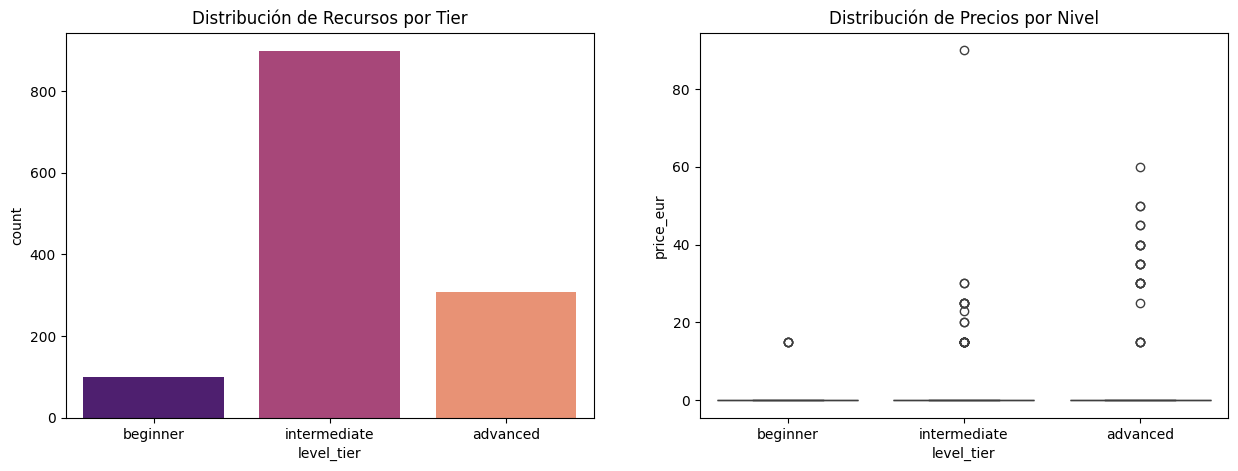

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de Tiers
sns.countplot(data=df, x='level_tier', palette='magma', ax=ax[0])
ax[0].set_title("Distribución de Recursos por Tier")

# Relación Precio vs Nivel
sns.boxplot(data=df, x='level_tier', y='price_eur', ax=ax[1])
ax[1].set_title("Distribución de Precios por Nivel")
plt.show()
